## Correlation Between News Sentiment & Stock Movement

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from nltk.sentiment import SentimentIntensityAnalyzer
from scipy.stats import pearsonr

stock_aapl = pd.read_csv("../data/raw/AAPL.csv")
stock_amzn = pd.read_csv("../data/raw/AMZN.csv")
stock_google = pd.read_csv("../data/raw/GOOG.csv")
stock_meta = pd.read_csv("../data/raw/META.csv")
stock_nvda = pd.read_csv("../data/raw/NVDA.csv")

news = pd.read_csv("../data/raw/raw_analyst_ratings.csv")

## stock data

In [2]:
stocks = {
    "AAPL": stock_aapl,
    "AMZN": stock_amzn,
    "GOOG": stock_google,
    "META": stock_meta,
    "NVDA": stock_nvda
}

for name, df in stocks.items():
    
    # Convert date column
    df['Date'] = pd.to_datetime(df['Date'])
    
    # Sort values
    df.sort_values('Date', inplace=True)
    
    # Calculate daily returns
    df['returns'] = df['Close'].pct_change() * 100

## news data

In [4]:
news['date'] = pd.to_datetime(
    news['date'],
    format='mixed',
    utc=True
)

# Remove timezone
news['date'] = news['date'].dt.tz_localize(None)

# Keep only date portion
news['Date'] = news['date'].dt.normalize()

## SENTIMENT ANALYSIS USING VADER

In [6]:

import nltk

nltk.download('vader_lexicon')
sia = SentimentIntensityAnalyzer()

news['sentiment'] = news['headline'].apply(
    lambda x: sia.polarity_scores(str(x))['compound']
)

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\redea\AppData\Roaming\nltk_data...


## ANALYSIS FUNCTION

In [17]:
from scipy.stats import pearsonr

def analyze_stock(stock_df, news_df, stock_name):

    stock_df = stock_df.copy()

    # Prepare stock dates
    stock_df['Date'] = pd.to_datetime(stock_df['Date'])

    stock_df.sort_values('Date', inplace=True)

    # Daily returns
    stock_df['returns'] = (
        stock_df['Close'].pct_change() * 100
    )

    # =================================================
    # FAST ALIGNMENT TO NEXT TRADING DAY
    # =================================================

    aligned = pd.merge_asof(
        news_df.sort_values('Date'),
        stock_df[['Date']].sort_values('Date'),
        on='Date',
        direction='forward'
    )

    # =================================================
    # DAILY SENTIMENT
    # =================================================

    daily_sentiment = (
        aligned
        .groupby('Date')['sentiment']
        .mean()
        .reset_index()
    )

    daily_sentiment.columns = ['Date', 'avg_sentiment']

    # =================================================
    # MERGE
    # =================================================

    merged = pd.merge(
        stock_df,
        daily_sentiment,
        on='Date',
        how='inner'
    )

    merged.dropna(
        subset=['returns', 'avg_sentiment'],
        inplace=True
    )

    # =================================================
    # CORRELATION
    # =================================================

    corr, p_value = pearsonr(
        merged['avg_sentiment'],
        merged['returns']
    )

    print(f"{stock_name}: {corr:.4f}")

    return merged, corr

## RUN ANALYSIS FOR ALL COMPANIES

In [18]:
results = {}

for name, df in stocks.items():

    merged_data, correlation = analyze_stock(
        df,
        news,
        name
    )

    results[name] = {
        "merged_data": merged_data,
        "correlation": correlation
    }

AAPL: 0.1448
AMZN: 0.0822
GOOG: 0.1254
META: 0.1481
NVDA: 0.1146


## SCATTER PLOT(APPLE)

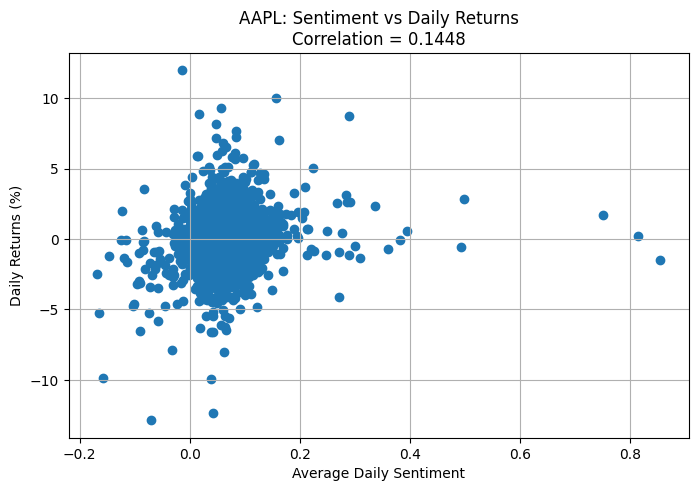

In [19]:
company = "AAPL"

data = results[company]['merged_data']
corr = results[company]['correlation']

plt.figure(figsize=(8,5))

plt.scatter(
    data['avg_sentiment'],
    data['returns']
)

plt.title(
    f"{company}: Sentiment vs Daily Returns\nCorrelation = {corr:.4f}"
)

plt.xlabel("Average Daily Sentiment")
plt.ylabel("Daily Returns (%)")

plt.grid(True)

plt.show()

## BAR CHART(APPLE)

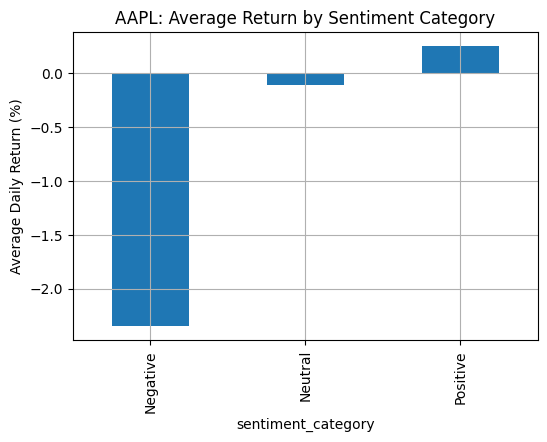

In [20]:
def classify_sentiment(x):

    if x > 0.05:
        return "Positive"

    elif x < -0.05:
        return "Negative"

    return "Neutral"

data['sentiment_category'] = data['avg_sentiment'].apply(
    classify_sentiment
)

category_returns = (
    data
    .groupby('sentiment_category')['returns']
    .mean()
)

plt.figure(figsize=(6,4))

category_returns.plot(kind='bar')

plt.title(
    f"{company}: Average Return by Sentiment Category"
)

plt.ylabel("Average Daily Return (%)")

plt.grid(True)

plt.show()

## SCATTER PLOT(AMAZON)

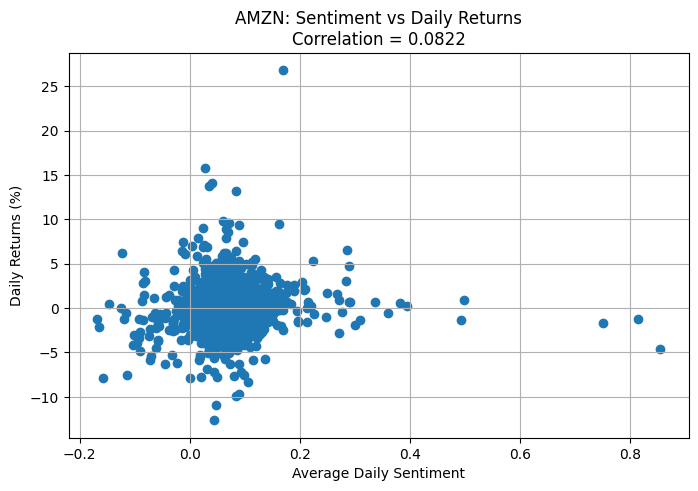

In [22]:
company = "AMZN"
data = results[company]['merged_data']
corr = results[company]['correlation']

plt.figure(figsize=(8,5))

plt.scatter(
    data['avg_sentiment'],
    data['returns']
)

plt.title(
    f"{company}: Sentiment vs Daily Returns\nCorrelation = {corr:.4f}"
)

plt.xlabel("Average Daily Sentiment")
plt.ylabel("Daily Returns (%)")

plt.grid(True)

plt.show()

## BAR CHART(AMAZON)

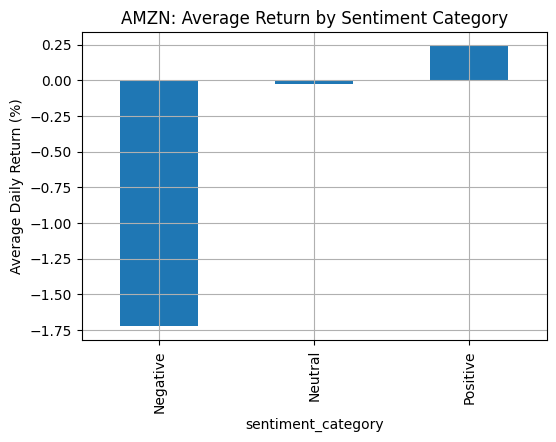

In [23]:
def classify_sentiment(x):

    if x > 0.05:
        return "Positive"

    elif x < -0.05:
        return "Negative"

    return "Neutral"

data['sentiment_category'] = data['avg_sentiment'].apply(
    classify_sentiment
)

category_returns = (
    data
    .groupby('sentiment_category')['returns']
    .mean()
)

plt.figure(figsize=(6,4))

category_returns.plot(kind='bar')

plt.title(
    f"{company}: Average Return by Sentiment Category"
)

plt.ylabel("Average Daily Return (%)")

plt.grid(True)

plt.show()

## SCATTER PLOT(GOOGLE)

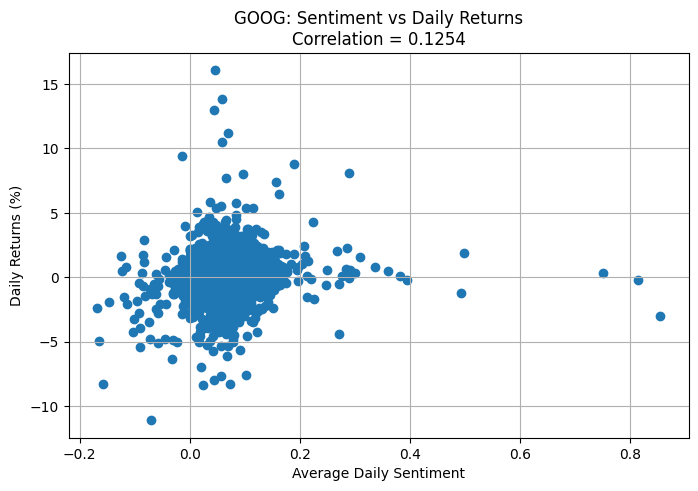

In [24]:
company = "GOOG"

data = results[company]['merged_data']
corr = results[company]['correlation']

plt.figure(figsize=(8,5))

plt.scatter(
    data['avg_sentiment'],
    data['returns']
)

plt.title(
    f"{company}: Sentiment vs Daily Returns\nCorrelation = {corr:.4f}"
)

plt.xlabel("Average Daily Sentiment")
plt.ylabel("Daily Returns (%)")

plt.grid(True)

plt.show()

## BAR CHART(GOOGLE)

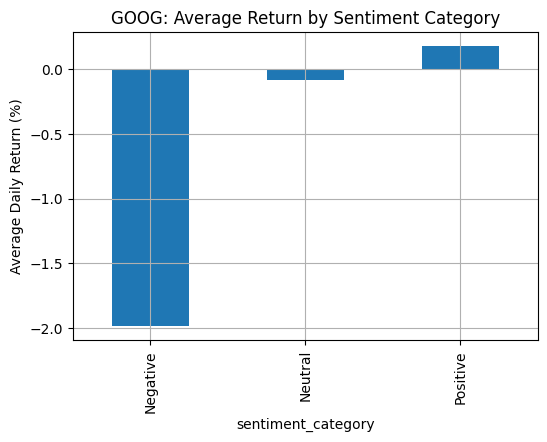

In [25]:
def classify_sentiment(x):

    if x > 0.05:
        return "Positive"

    elif x < -0.05:
        return "Negative"

    return "Neutral"

data['sentiment_category'] = data['avg_sentiment'].apply(
    classify_sentiment
)

category_returns = (
    data
    .groupby('sentiment_category')['returns']
    .mean()
)

plt.figure(figsize=(6,4))

category_returns.plot(kind='bar')

plt.title(
    f"{company}: Average Return by Sentiment Category"
)

plt.ylabel("Average Daily Return (%)")

plt.grid(True)

plt.show()

## SCATTER PLOT(META)

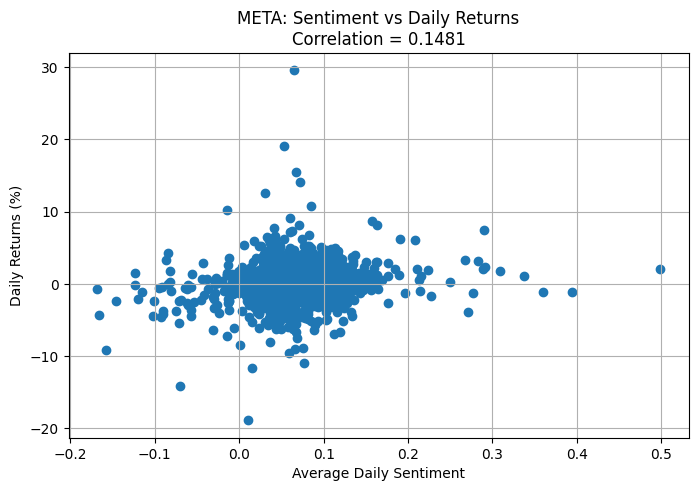

In [26]:
company = "META"

data = results[company]['merged_data']
corr = results[company]['correlation']

plt.figure(figsize=(8,5))

plt.scatter(
    data['avg_sentiment'],
    data['returns']
)

plt.title(
    f"{company}: Sentiment vs Daily Returns\nCorrelation = {corr:.4f}"
)

plt.xlabel("Average Daily Sentiment")
plt.ylabel("Daily Returns (%)")

plt.grid(True)

plt.show()

## BAR CHART(META)

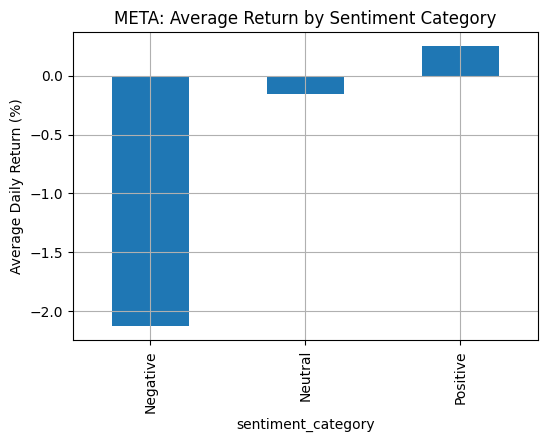

In [27]:
def classify_sentiment(x):

    if x > 0.05:
        return "Positive"

    elif x < -0.05:
        return "Negative"

    return "Neutral"

data['sentiment_category'] = data['avg_sentiment'].apply(
    classify_sentiment
)

category_returns = (
    data
    .groupby('sentiment_category')['returns']
    .mean()
)

plt.figure(figsize=(6,4))

category_returns.plot(kind='bar')

plt.title(
    f"{company}: Average Return by Sentiment Category"
)

plt.ylabel("Average Daily Return (%)")

plt.grid(True)

plt.show()

## SCATTER PLOT(NVDA)

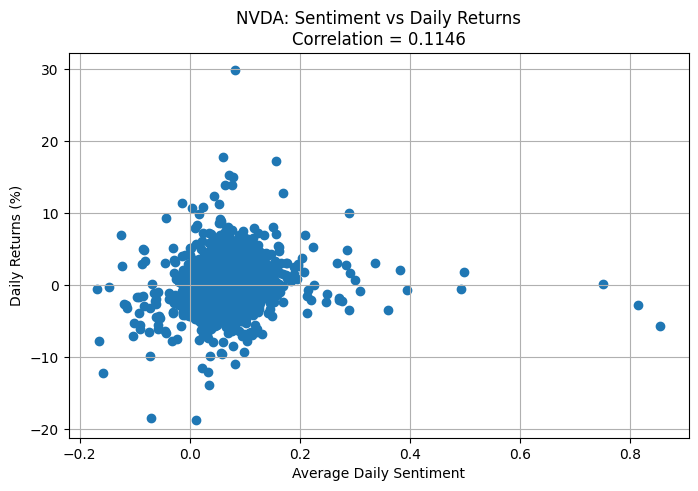

In [28]:
company = "NVDA"

data = results[company]['merged_data']
corr = results[company]['correlation']

plt.figure(figsize=(8,5))

plt.scatter(
    data['avg_sentiment'],
    data['returns']
)

plt.title(
    f"{company}: Sentiment vs Daily Returns\nCorrelation = {corr:.4f}"
)

plt.xlabel("Average Daily Sentiment")
plt.ylabel("Daily Returns (%)")

plt.grid(True)

plt.show()

## BAR CHART(NVDA)

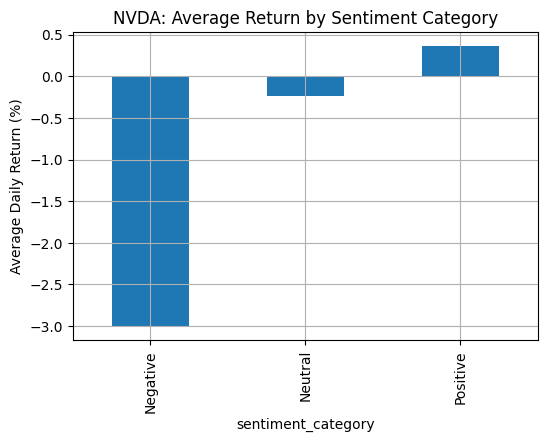

In [29]:
def classify_sentiment(x):

    if x > 0.05:
        return "Positive"

    elif x < -0.05:
        return "Negative"

    return "Neutral"

data['sentiment_category'] = data['avg_sentiment'].apply(
    classify_sentiment
)

category_returns = (
    data
    .groupby('sentiment_category')['returns']
    .mean()
)

plt.figure(figsize=(6,4))

category_returns.plot(kind='bar')

plt.title(
    f"{company}: Average Return by Sentiment Category"
)

plt.ylabel("Average Daily Return (%)")

plt.grid(True)

plt.show()

## COMPARISON TABLE

In [30]:
comparison = pd.DataFrame({
    "Company": results.keys(),
    "Correlation": [
        results[x]['correlation']
        for x in results
    ]
})

comparison.sort_values(
    by='Correlation',
    ascending=False,
    inplace=True
)

comparison

,Company,Correlation
3,META,0.148149
0,AAPL,0.144781
2,GOOG,0.125444
4,NVDA,0.114627
1,AMZN,0.082240


## 📊 Interpretation of Results

The analysis explored the relationship between financial news sentiment and daily stock returns for multiple technology companies including AAPL, AMZN, GOOG, META, and NVDA.

Pearson correlation coefficients were calculated between average daily sentiment scores and stock returns. The results indicate whether positive or negative news sentiment tends to align with positive or negative market performance.

Scatter plots were used to visualize the relationship between sentiment and returns, while bar charts compared average returns across positive, neutral, and negative sentiment categories.

### Limitations

- Financial markets are influenced by many external factors beyond news sentiment
- News effects may occur with delayed market reactions
- Sentiment analysis models may not fully capture financial context or sarcasm
- The same global news dataset was applied across all companies, which may dilute company-specific sentiment effects